In [1]:
!pip install catboost
import pandas as pd
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier, Pool

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.0 MB/s eta 0:00:00


In [2]:
gs = pd.read_csv('/content/drive/MyDrive/S2_Polygon_MeanBands_2025.csv')

In [3]:
print(gs.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175 entries, 0 to 174
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   system:index  175 non-null    object 
 1   B11           170 non-null    float64
 2   B12           170 non-null    float64
 3   B2            170 non-null    float64
 4   B3            170 non-null    float64
 5   B4            170 non-null    float64
 6   B8            170 non-null    float64
 7   Class         175 non-null    object 
 8   fid           175 non-null    int64  
 9   .geo          175 non-null    object 
dtypes: float64(6), int64(1), object(3)
memory usage: 13.8+ KB
None


In [5]:
df = gs.drop(columns=['fid', 'system:index'], errors='ignore', inplace=False)

# Add a 'poly_id2' column as a sequential integer index
df.insert(0, 'poly_id2', range(len(df)))

df = df[df['Class'].isin(['Green_residential','Urban','Parkland','Water'])]

new_columns = []
for col in df.columns:
    if 'S2_Polygon_BandMeans_' in col:
        new_columns.append(col.replace('S2_Polygon_BandMeans_', ''))
    else:
        new_columns.append(col)
df.columns = new_columns

In [6]:
df =df.drop(columns='.geo',inplace=False)

In [7]:
df.head()

,poly_id2,B11,B12,B2,B3,B4,B8,Class
1,1,2143.687474,1698.986986,706.685683,909.793453,975.422957,2215.525145,Green_residential
2,2,1989.147227,1535.141306,662.414016,864.618091,922.346155,2147.578862,Green_residential
3,3,1739.634692,1448.281831,551.748242,700.814630,781.990991,1890.829263,Green_residential
4,4,1610.623289,1273.501686,418.315492,568.389131,623.130272,1904.532715,Green_residential
5,5,1617.588856,1298.270655,433.049588,589.774461,647.646039,1884.168631,Green_residential


In [9]:
# drop nulls
df.dropna(inplace=True)

In [13]:
# Define features (X) and target (y)
y = df['Class']
X = df.drop(columns=['Class'])

# Identify categorical features for CatBoost
import numpy as np
categorical_features_indices = np.where(X.dtypes == 'object')[0]

# Split the data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

from sklearn.metrics import classification_report

# Initialize CatBoostClassifier
model = CatBoostClassifier(iterations=100,  # You can adjust this
                           learning_rate=0.1, # You can adjust this
                           depth=6,           # You can adjust this
                           loss_function='MultiClass', # For multi-class classification
                           eval_metric='Accuracy',
                           random_seed=42,
                           verbose=False) # Set to True for progress updates

# Train the model
model.fit(X_train, y_train, cat_features=categorical_features_indices)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Print classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
                   precision    recall  f1-score   support

Green_residential       1.00      1.00      1.00         8
         Parkland       1.00      1.00      1.00         9
            Urban       1.00      1.00      1.00         8
            Water       1.00      1.00      1.00         9

         accuracy                           1.00        34
        macro avg       1.00      1.00      1.00        34
     weighted avg       1.00      1.00      1.00        34



# Task
Load the new `London_S2_Composite_2024.tif` file using `rasterio`. Extract the relevant Sentinel-2 band data (B11, B12, B2, B3, B4, B8) from the GeoTIFF, assuming they are in the specified order. Reshape this data into a pandas DataFrame, adding a `poly_id2` column with sequential indices, and handle any NaN values by dropping rows containing them. Then, apply the trained `CatBoostClassifier` model to predict the class for each pixel. Finally, reshape the predicted classes back into a 2D array matching the original raster's spatial dimensions, save this classified raster as a new GeoTIFF file, and visualize the classified raster with a legend.

## Load New GeoTIFF and Inspect Bands

### Subtask:
Load the new `London_S2_Composite_2024.tif` file using `rasterio`. Inspect its metadata to determine the number of bands and their corresponding order or names, which is crucial for correctly extracting the input features for the model (B11, B12, B2, B3, B4, B8).


**Reasoning**:
The subtask requires loading a GeoTIFF file and inspecting its metadata. I will use `rasterio` to open the file and print its profile and band descriptions to understand the band structure.



In [17]:
import rasterio

# Define the path to the GeoTIFF file
geotiff_path = '/content/drive/MyDrive/GEE_Exports/London_S2_Composite_2024.tif'

# Open the GeoTIFF file using rasterio
with rasterio.open(geotiff_path) as src:
    # Print the dataset's metadata (profile)
    print("GeoTIFF Profile:")
    for key, value in src.profile.items():
      print(f"  {key}: {value}")

    # Print band descriptions if available
    print("\nBand Descriptions:")
    if src.descriptions:
        for i, desc in enumerate(src.descriptions):
            print(f"  Band {i+1}: {desc}")
    else:
        print("  Band descriptions not available. Bands are typically ordered numerically.")


GeoTIFF Profile:
  driver: GTiff
  dtype: float32
  nodata: None
  width: 651
  height: 233
  count: 6
  crs: EPSG:4326
  transform: | 0.00, 0.00,-0.14|
| 0.00,-0.00, 51.52|
| 0.00, 0.00, 1.00|
  blockxsize: 256
  blockysize: 256
  tiled: True
  compress: lzw
  interleave: pixel

Band Descriptions:
  Band 1: B2
  Band 2: B3
  Band 3: B4
  Band 4: B8
  Band 5: B11
  Band 6: B12


In [21]:
import rasterio
import os

# Define the path to the GeoTIFF file with the corrected directory name
geotiff_path = '/content/drive/MyDrive/GEE_Exports/London_S2_Composite_2024.tif'
geotiff_dir = os.path.dirname(geotiff_path)

# Check if the file exists
if not os.path.exists(geotiff_path):
    print(f"Error: The file '{geotiff_path}' was not found. Please ensure it exists in your Google Drive and the path is correct.")
    # Attempt to list directory contents to help locate the file
    if os.path.exists(geotiff_dir):
        print(f"Contents of '{geotiff_dir}':")
        for item in os.listdir(geotiff_dir):
            print(f"  - {item}")
    else:
        print(f"Error: The directory '{geotiff_dir}' was not found. Checking parent directory '/content/drive/MyDrive/'.")
        mydrive_dir = '/content/drive/MyDrive/'
        if os.path.exists(mydrive_dir):
            print(f"Contents of '{mydrive_dir}':")
            for item in os.listdir(mydrive_dir):
                print(f"  - {item}")
        else:
            print("Error: Google Drive not mounted or '/content/drive/MyDrive/' does not exist. Please mount Google Drive and verify its structure.")
else:
    # Open the GeoTIFF file using rasterio
    with rasterio.open(geotiff_path) as src:
        # Print the dataset's metadata (profile)
        print("GeoTIFF Profile:")
        for key, value in src.profile.items():
          print(f"  {key}: {value}")

        # Print band descriptions if available
        print("\nBand Descriptions:")
        if src.descriptions:
            for i, desc in enumerate(src.descriptions):
                print(f"  Band {i+1}: {desc}")
        else:
            print("  Band descriptions not available. Bands are typically ordered numerically.")

GeoTIFF Profile:
  driver: GTiff
  dtype: float32
  nodata: None
  width: 651
  height: 233
  count: 6
  crs: EPSG:4326
  transform: | 0.00, 0.00,-0.14|
| 0.00,-0.00, 51.52|
| 0.00, 0.00, 1.00|
  blockxsize: 256
  blockysize: 256
  tiled: True
  compress: lzw
  interleave: pixel

Band Descriptions:
  Band 1: B2
  Band 2: B3
  Band 3: B4
  Band 4: B8
  Band 5: B11
  Band 6: B12


In [22]:
import rasterio
import pandas as pd
import numpy as np

geotiff_path = '/content/drive/MyDrive/GEE_Exports/London_S2_Composite_2024.tif'

# Open the GeoTIFF file and read its metadata
with rasterio.open(geotiff_path) as src:
    # Store the GeoTIFF's profile and dimensions for later use
    london_profile = src.profile
    london_width = src.width
    london_height = src.height

    # Read the bands in the order B11, B12, B2, B3, B4, B8, as required by the model
    # Based on the previous output:
    # Band 1: B2, Band 2: B3, Band 3: B4, Band 4: B8, Band 5: B11, Band 6: B12
    # So, we need to read them in the sequence 5, 6, 1, 2, 3, 4
    band_b11 = src.read(5)
    band_b12 = src.read(6)
    band_b2 = src.read(1)
    band_b3 = src.read(2)
    band_b4 = src.read(3)
    band_b8 = src.read(4)

    # Stack the bands into a single numpy array with shape (num_bands, height, width)
    london_image = np.stack([band_b11, band_b12, band_b2, band_b3, band_b4, band_b8])

# Transpose the array to (height, width, num_bands) for easier reshaping
london_image_transposed = london_image.transpose(1, 2, 0)

# Reshape the data to a 2D array (height * width, num_bands)
london_image_reshaped = london_image_transposed.reshape(-1, london_image_transposed.shape[-1])

# Create a DataFrame from the reshaped data
# The column names must match the features used for training the model (X_train columns)
model_features = ['B11', 'B12', 'B2', 'B3', 'B4', 'B8'] # Exclude 'poly_id2' as it's an index
london_df_for_prediction = pd.DataFrame(london_image_reshaped, columns=model_features)

# Add a 'poly_id2' column with sequential indices, as it was present in the training data
london_df_for_prediction.insert(0, 'poly_id2', range(len(london_df_for_prediction)))

# Drop rows that contain NaN values, as the model cannot handle them
initial_row_count = len(london_df_for_prediction)
london_df_for_prediction.dropna(inplace=True)

# Print information about the processed DataFrame
print(f"Initial number of pixels: {initial_row_count}")
print(f"Number of pixels after dropping NaNs: {len(london_df_for_prediction)}")
print("\nDataFrame info after processing GeoTIFF bands:")
print(london_df_for_prediction.info())
display(london_df_for_prediction.head())

Initial number of pixels: 151683
Number of pixels after dropping NaNs: 151683

DataFrame info after processing GeoTIFF bands:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151683 entries, 0 to 151682
Data columns (total 7 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   poly_id2  151683 non-null  int64  
 1   B11       151683 non-null  float32
 2   B12       151683 non-null  float32
 3   B2        151683 non-null  float32
 4   B3        151683 non-null  float32
 5   B4        151683 non-null  float32
 6   B8        151683 non-null  float32
dtypes: float32(6), int64(1)
memory usage: 4.6 MB
None


,poly_id2,B11,B12,B2,B3,B4,B8
0,0,0.109271,0.098014,0.070229,0.073600,0.075814,0.082471
1,1,0.109271,0.098014,0.070229,0.073600,0.075814,0.082471
2,2,0.109271,0.098014,0.046571,0.047171,0.054971,0.062657
3,3,0.107886,0.092071,0.072386,0.076614,0.084057,0.088714
4,4,0.107886,0.092071,0.072386,0.076614,0.084057,0.088714


In [23]:
london_pixel_predictions = model.predict(london_df_for_prediction)

# Add the predictions back to the DataFrame
london_df_for_prediction['Predicted_Class'] = london_pixel_predictions.flatten()

print("Predictions generated successfully.")
display(london_df_for_prediction.head())

Predictions generated successfully.


,poly_id2,B11,B12,B2,B3,B4,B8,Predicted_Class
0,0,0.109271,0.098014,0.070229,0.073600,0.075814,0.082471,Green_residential
1,1,0.109271,0.098014,0.070229,0.073600,0.075814,0.082471,Green_residential
2,2,0.109271,0.098014,0.046571,0.047171,0.054971,0.062657,Green_residential
3,3,0.107886,0.092071,0.072386,0.076614,0.084057,0.088714,Green_residential
4,4,0.107886,0.092071,0.072386,0.076614,0.084057,0.088714,Green_residential


In [25]:
import numpy as np

# Get the predicted classes as a 1D array
classified_pixels = london_df_for_prediction['Predicted_Class'].values

# Map class labels to numerical values for raster output
# This assumes 'Green_residential', 'Parkland', 'Urban' are the classes.
# You might need to adjust these mappings based on your specific classes and desired output values.
class_to_value = {
    'Green_residential': 1,
    'Parkland': 2,
    'Urban': 3,
    'Water': 4
}

# Apply the mapping to the classified pixels
numerical_classified_pixels = np.array([class_to_value[c] for c in classified_pixels])

# Reshape the 1D array of numerical predictions back to the original raster dimensions
# Use london_height and london_width stored earlier from src.height and src.width
classified_raster = numerical_classified_pixels.reshape(london_height, london_width)

print(f"Reshaped classified raster has dimensions: {classified_raster.shape}")
print("First 5 rows and columns of the classified raster (numerical values):")
print(classified_raster[:5, :5])

Reshaped classified raster has dimensions: (233, 651)
First 5 rows and columns of the classified raster (numerical values):
[[1 1 1 1 1]
 [4 4 4 4 4]
 [4 4 4 4 4]
 [4 4 4 4 4]
 [4 4 4 4 4]]


In [26]:
import rasterio
import numpy as np

# Define the output file path
output_geotiff_path = '/content/London_S2_classified.tif'

# Update the profile for the new classified raster
# The classified_raster is a single band (count=1) of integer values (dtype=np.int8 or np.int16)
output_profile = london_profile.copy()
output_profile.update({
    'dtype': np.int8,  # Use a data type that can hold the class values (1, 2, 3)
    'count': 1,        # The classified raster has only one band
    'nodata': 0        # Assuming 0 can be used for nodata, or ensure all pixels have a class
})

# Write the classified raster to a new GeoTIFF file
with rasterio.open(output_geotiff_path, 'w', **output_profile) as dst:
    dst.write(classified_raster.astype(output_profile['dtype']), 1) # Write the single band

print(f"Classified raster saved to: {output_geotiff_path}")

Classified raster saved to: /content/London_S2_classified.tif


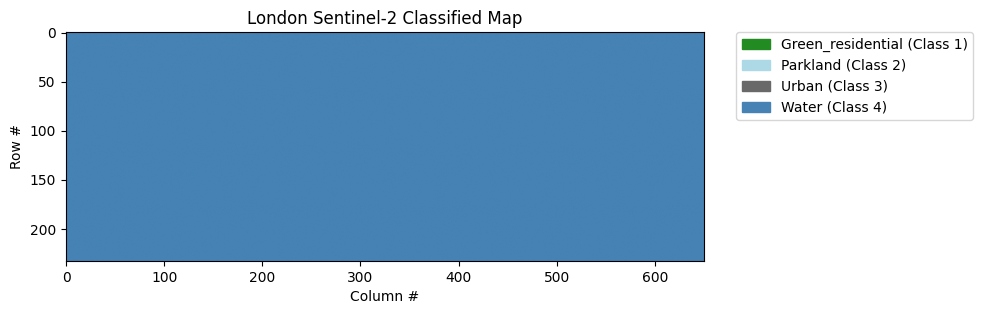

In [28]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# Define the output file path
output_geotiff_path = '/content/London_S2_classified.tif'

# Open the classified GeoTIFF file
with rasterio.open(output_geotiff_path) as src:
    classified_map = src.read(1) # Read the single classified band

# Define colors for each class
# Ensure these colors are distinct and easily distinguishable
colors = [
    '#228B22', # ForestGreen for Green_residential
    '#ADD8E6', # LightBlue for Parkland
    '#696969',  # DimGray for Urban
    '#4682B4'  # SteelBlue for Water (added)
]
class_names = list(class_to_value.keys())

# Create a colormap from the defined colors
cmap = ListedColormap(colors)

# Normalize the colormap to the range of class values (1 to 3)
# Bounds should be from min_val to max_val+1 for discrete colormaps
norm = plt.Normalize(vmin=1, vmax=len(class_names))

# Create a figure and an axes object for the plot
fig, ax = plt.subplots(figsize=(10, 8))

# Display the classified map
im = ax.imshow(classified_map, cmap=cmap, norm=norm)

# Create custom legend handles
patches = [Patch(color=colors[i], label=f'{class_names[i]} (Class {i+1})') for i in range(len(class_names))]
ax.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

ax.set_title('London Sentinel-2 Classified Map')
ax.set_xlabel('Column #')
ax.set_ylabel('Row #')

plt.tight_layout()
plt.show()